In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import sys
import astropy as ast
from astropy.io import ascii
import matplotlib.pyplot as plt
import pandas as pd
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm, Normalize
from matplotlib.lines import Line2D
import matplotlib.path as mpath
fourpointstar = mpath.Path.unit_regular_star(4)
sevenpointstar = mpath.Path.unit_regular_star(7)
eightpointstar = mpath.Path.unit_regular_star(8)
from metrics import fit_plotter_flux, compute_lomb_scargle, plot_periodogram, info, plot_phase_fold_binned, plot_phase_fold

In [2]:
stats = pd.read_csv('../summary_results03162026.csv')
df_smc = stats[stats['RA'] < 40]
df_lmc = stats[stats['RA'] > 40]
coords = pd.read_csv('../merged_smc_lmc_coords_all.csv', comment='#', sep="\\s+", names=['RA', 'DEC'])
hrd_zoning = pd.read_csv('./HRD_zoning_priority_03222026.csv')
# temps = pd.read_csv('../synth_phot_temp_estimation/ysg_temp_fitting_summary_v10_prefinal.csv')
temps = pd.read_csv('../synth_phot_temp_estimation/ysg_temp_fitting_summary_03152026.csv')
var = pd.read_csv('../summary_results03162026.csv')
hrd_priority = pd.read_csv("HRD_zoning_priority_03202026.csv")
magellan_spectroscopy_orig = pd.read_csv("../magellan_spectroscopy/magellan_spectroscopy_to_original_matches.csv")
magellan_spectroscopy_prefinal = pd.read_csv("../magellan_spectroscopy/magellan_spectroscopy_to_prefinal_matches.csv")
plt.rcParams['font.family'] = 'serif'

In [3]:
offsets = pd.read_csv("../offsets.csv")
print(offsets['discard_lc'].sum(), "light curves discarded due to bad offsets")
print(var['alarm_level_flag'].sum(), "light curves discarded due to no significant period")
print(var['logT'].isna().sum(), "light curves discarded due to no temperature estimate")
print((var['alarm_level_flag']==0).sum(), "light curves kept")
print(((var['SIMBAD_maintype']== 'ClassicalCep') & (var['alarm_level_flag']==0)).sum())
print(((var['SIMBAD_maintype']== 'LongPeriodV*') & (var['alarm_level_flag']==0)).sum())
print(((var['SIMBAD_maintype']== 'ChemPec*') & (var['alarm_level_flag']==0)).sum())
print(((var['SIMBAD_maintype']== 'EmLine*') & (var['alarm_level_flag']==0)).sum())
print(((var['SIMBAD_maintype']== 'PulsV*') & (var['alarm_level_flag']==0)).sum())
print(((var['SIMBAD_maintype']== 'EclBin') & (var['alarm_level_flag']==0)).sum())
print(((var['SIMBAD_maintype']== 'HighPM*') & (var['alarm_level_flag']==0)).sum())
print(((var['SIMBAD_maintype']== 'WolfRayet*') & (var['alarm_level_flag']==0)).sum())

93.0 light curves discarded due to bad offsets
167.0 light curves discarded due to no significant period
11 light curves discarded due to no temperature estimate
1011 light curves kept
74
29
19
20
2
2
3
10


# Summary HRDs; case-by-case work after this section

/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_26385/2710631228.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(tick_labels)


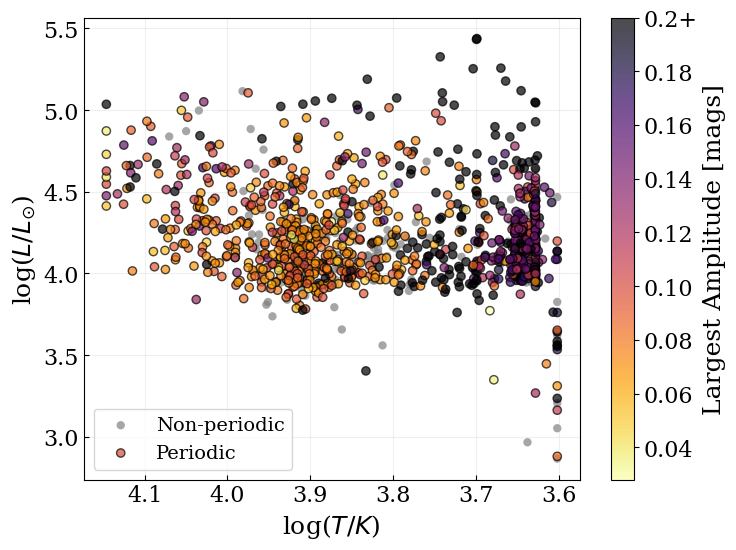

In [4]:
def basic_HRD(column, cbar_label='Largest Amplitude [mJy]'):
    """
    Plot LMC and SMC HR diagrams together with one colorbar.
    """
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=(8, 6))
    c = stats[column]
    mask = (stats['alarm_level_flag'] == 0).values
    nonvar_mask = (stats['alarm_level_flag'] == 1).values
    vmax = np.max(c[mask])
    vmax = 0.2
    # vmax = 80
    vmin = 0
    # norm_smc = Normalize(vmin=np.min(smc_c[mask_smc]), vmax=np.max(smc_c[mask_smc]))

    sc01 = ax.scatter(stats['logT'].values[nonvar_mask], stats['logL'].values[nonvar_mask], c='gray', alpha=0.7, edgecolors='none', label='Non-periodic')
    # LMC
    sc1 = ax.scatter(stats['logT'].values[mask], stats['logL'].values[mask],
                    c=c[mask], cmap='inferno_r', norm=Normalize(vmin=np.min(c[mask]), vmax=vmax),
                    alpha=0.7, zorder=10, edgecolors='black', label='Periodic')
    # ax.set_xlim(3.9, 3.95)
    # ax.set_ylim(4.2,4.4)
    ax.invert_xaxis()
    ax.set_xlabel('log($T/K$)', fontsize=18) # /K
    ax.set_ylabel('log($L/L_{\\odot}$)', fontsize=18) #L_{\odot} 
    cbar = fig.colorbar(sc1, ax=ax, orientation='vertical')
    cbar.set_label(cbar_label, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    ticks = cbar.get_ticks()
    # tick_labels = [f'{tick:.0f}' for tick in ticks]
    # tick_labels[-1] = '80+'

    tick_labels = [f'{tick:.2f}' for tick in ticks]
    tick_labels[-1] = '0.2+'

    # cbar.set_ticks(ticks)
    cbar.set_ticklabels(tick_labels)
    plt.legend(loc='lower left', fontsize=14)
    plt.tick_params(axis='both', which='both', direction = 'in', labelsize=16)
    plt.grid(True, alpha=0.2)
    # plt.savefig(f'hr_diagrams/HR_{column}_shortened.png', dpi=300, bbox_inches='tight')
    plt.show()

basic_HRD('mag_amplitude_1', cbar_label='Largest Amplitude [mags]')# basic_HRD('best_period', cbar_label='Dominant Period [days]')


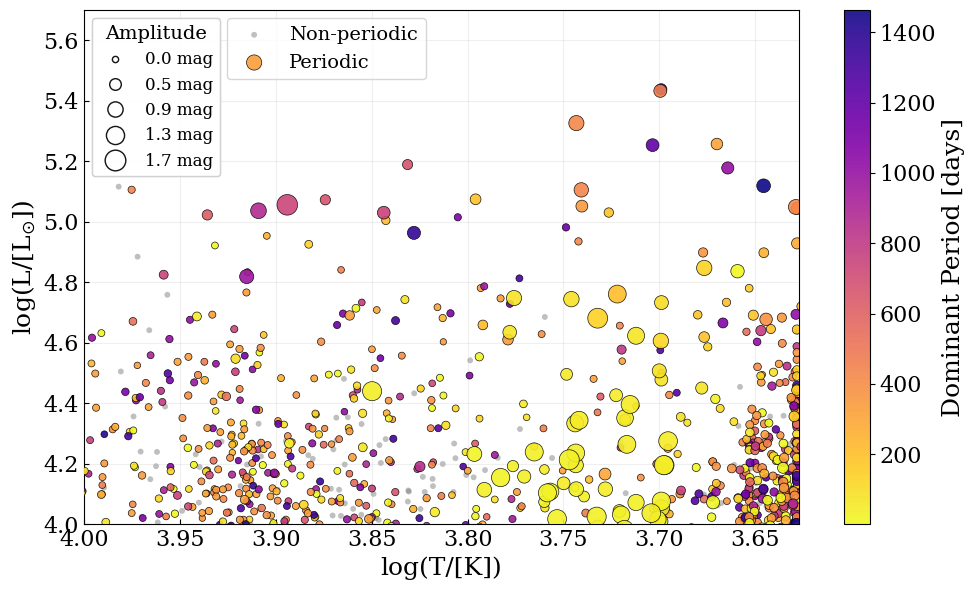

In [5]:
def basic_HRD_period_color_size_amp(
    period_col='best_period',
    amp_col='mag_amplitude_1',
    cbar_label='Dominant Period [days]',
    size_range=(20, 220),
    period_vmin=None,
    period_vmax=None,
):
    """
    HRD where:
    - marker color = best_period
    - marker size = mag_amplitude_1 (normalized)
    """
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=(10, 6))

    # Masks
    periodic_mask = (stats['alarm_level_flag'] == 0).values
    nonperiodic_mask = (stats['alarm_level_flag'] == 1).values

    # Non-periodic background
    ax.scatter(
        stats['logT'].values[nonperiodic_mask],
        stats['logL'].values[nonperiodic_mask],
        c='gray',
        s=18,
        alpha=0.5,
        edgecolors='none',
        label='Non-periodic',
        zorder=1
    )

    # Keep only valid periodic rows for color+size mapping
    valid = (
        periodic_mask
        & stats['logT'].notna().values
        & stats['logL'].notna().values
        & stats[period_col].notna().values
        & stats[amp_col].notna().values
        & (stats['alarm_level_flag'].values == 0)
    )

    x = stats.loc[valid, 'logT'].values
    y = stats.loc[valid, 'logL'].values
    period_vals = stats.loc[valid, period_col].values.astype(float)
    amp_vals = stats.loc[valid, amp_col].values.astype(float)

    # Normalize amplitude -> marker size
    amp_min = np.nanmin(amp_vals)
    amp_max = np.nanmax(amp_vals)
    smin, smax = size_range

    if np.isclose(amp_min, amp_max):
        sizes = np.full_like(amp_vals, (smin + smax) / 2.0, dtype=float)
    else:
        amp_norm = (amp_vals - amp_min) / (amp_max - amp_min)
        sizes = smin + amp_norm * (smax - smin)

    # Normalize period -> color
    if period_vmin is None:
        period_vmin = np.nanmin(period_vals)
    if period_vmax is None:
        period_vmax = np.nanmax(period_vals)
    norm = Normalize(vmin=period_vmin, vmax=period_vmax)

        # Sort by amplitude so small points are drawn first, large points last
    order = np.argsort(amp_vals)  # ascending
    x_plot = x[order]
    y_plot = y[order]
    period_plot = period_vals[order]
    amp_plot = amp_vals[order]
    sizes_plot = sizes[order]

    sc = ax.scatter(
        x_plot, y_plot,
        c=period_plot,
        s=sizes_plot,
        cmap='plasma_r',
        norm=norm,
        alpha=0.9,
        edgecolors='black',
        linewidths=0.5,
        label='Periodic',
        zorder=10
    )


    # Keep your existing legend for categories/colors
    main_legend = ax.legend(loc=[0.20, 0.865], fontsize=14)
    ax.add_artist(main_legend)

    # Build 5 reference amplitude values for marker-size legend
    amp_legend_vals = np.linspace(amp_min, amp_max, 5)

    if np.isclose(amp_min, amp_max):
        amp_legend_sizes = np.full(5, (smin + smax) / 2.0)
    else:
        amp_legend_sizes = smin + (amp_legend_vals - amp_min) / (amp_max - amp_min) * (smax - smin)

    # IMPORTANT: scatter 's' is area (pt^2), but legend markersize is radius-like (pt)
    size_handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markerfacecolor='white',
            markeredgecolor='black',
            alpha=0.9,
            markersize=np.sqrt(s),
            label=f'{v:.1f} mag'
        )
        for v, s in zip(amp_legend_vals, amp_legend_sizes)
    ]
    # periodicity_legend = ax.legend(
    #     handles=,
    #     title='Periodicity',
    #     loc='upper right',
    #     frameon=True,
    #     fontsize=11,
    #     title_fontsize=12
    # )

    size_legend = ax.legend(
        handles=size_handles,
        title='Amplitude',
        loc='upper left',
        frameon=True,
        fontsize=12,
        title_fontsize=14
    )
    ax.add_artist(size_legend)
    # ax.add_artist(periodicity_legend)

    ax.set_xlim(3.627, 4.0)
    ax.set_ylim(4.0,5.7)

    ax.invert_xaxis()
    ax.set_xlabel('log(T/[K])', fontsize=18)
    ax.set_ylabel('log(L/[L$_{\\odot}$])', fontsize=18)

    cbar = fig.colorbar(sc, ax=ax, orientation='vertical')
    cbar.set_label(cbar_label, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    # ax.legend(loc='upper right', fontsize=14)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=16)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    # plt.savefig(f'hr_diagrams/Bowes_HR_{period_col}_color_{amp_col}_size.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'hr_diagrams/Bowes_figure.pdf', dpi=300, bbox_inches='tight')
    plt.show()


# Example call
basic_HRD_period_color_size_amp(
    period_col='best_period',
    amp_col='mag_amplitude_1',
    cbar_label='Dominant Period [days]'
)

In [6]:
def hrd_snippet(column, cbar_label='Largest Amplitude [mJy]'):
    """
    Plot LMC and SMC HR diagrams together with one colorbar.
    """
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=(8, 6))
    # LMC and SMC are separated because T, L are stored in separate files
    zone_mask = (stats['logT'] > 3.9) & (stats['logT'] < 3.95) & (stats['logL'] > 4.2) & (stats['logL'] < 4.4)
    mask = (stats['alarm_level_flag'] == 0).values
    nonvar_mask = (stats['alarm_level_flag'] == 1).values
    mask = mask & zone_mask
    nonvar_mask = nonvar_mask & zone_mask
    c = stats[column][mask]
    vmax = np.max(c[mask])
    # vmax = 0.2
    # vmax = 80
    vmin = 0
    # norm_smc = Normalize(vmin=np.min(smc_c[mask_smc]), vmax=np.max(smc_c[mask_smc]))

    sc01 = ax.scatter(stats['logT'].values[nonvar_mask], stats['logL'].values[nonvar_mask], c='gray', alpha=0.2, edgecolors='none', label='Non-periodic')
    # LMC
    sc1 = ax.scatter(stats['logT'].values[mask], stats['logL'].values[mask],
                    c=c[mask], cmap='inferno_r', norm=Normalize(vmin=np.min(c[mask]), vmax=vmax),
                    alpha=0.7, zorder=10, edgecolors='black', label='Periodic')
    # ax.set_xlim(3.9, 3.95)
    # ax.set_ylim(4.2,4.4)
    ax.invert_xaxis()
    ax.set_xlabel('log($T/[K]$)', fontsize=18) # /K
    ax.set_ylabel('log($L/[L_{\\odot}]$)', fontsize=18) #L_{\odot} 
    cbar = fig.colorbar(sc1, ax=ax, orientation='vertical')
    cbar.set_label(cbar_label, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    ticks = cbar.get_ticks()
    # tick_labels = [f'{tick:.0f}' for tick in ticks]
    # tick_labels[-1] = '80+'

    tick_labels = [f'{tick:.2f}' for tick in ticks]
    tick_labels[-1] = '0.2+'

    # cbar.set_ticks(ticks)
    cbar.set_ticklabels(tick_labels)
    plt.legend(loc='lower left', fontsize=14)
    plt.tick_params(axis='both', which='both', direction = 'in', labelsize=16)
    plt.grid(True, alpha=0.2)
    # plt.savefig(f'hr_diagrams/HR_{column}_shortened.png', dpi=300, bbox_inches='tight')
    plt.show()

# hrd_snippet('mag_amplitude_1', cbar_label='Largest Amplitude [mags]')# hrd_snippet('best_period', cbar_label='Dominant Period [days]')


In [7]:
def mag_amplitude_plot(column, clim):
    plt.figure(figsize=(14, 6))
    c = stats[column]
    mask = (stats['offset_flag'] == 0).values
    variable_mask = (stats['alarm_level_flag'] == 0).values
    nonvariable_mask = (stats['alarm_level_flag'] == 1).values
    # Combine both masks: only select rows where both are True
    var_mask = mask & variable_mask
    nonvar_mask = mask & nonvariable_mask
    sc2 = plt.scatter(stats['overall_mean_mag'][nonvar_mask], stats['mag_amplitude_1'][nonvar_mask], c='gray', alpha=0.7, edgecolors='none', label='Non-periodic', zorder=1)
    sc1 = plt.scatter(stats['overall_mean_mag'][var_mask], stats['mag_amplitude_1'][var_mask], c=c[var_mask], cmap='inferno', alpha=0.6, edgecolors='black', label = 'Periodic Variable', zorder=2)
    # sc2 = plt.scatter(stats['overall_mean_mag'][nonvar_mask], stats['mag_amplitude_1'][nonvar_mask], c='gray', alpha=0.5, edgecolors='none', label='Non-variable')
    plt.clim(0, clim)
    cbar = plt.colorbar(sc1)
    cbar.set_label('Dominant Period [days]', fontsize=20)
    cbar.ax.tick_params(labelsize=20)
    plt.legend(fontsize=20)
    plt.tick_params(axis='both', which='both', direction='in', labelsize=20)
    # plt.xticks(fontsize=20)
    # plt.yticks(fontsize=20)
    plt.xlabel('Mean Magnitude (g)', fontsize=20)
    plt.ylabel('Amplitude [mag]', fontsize=20)
    plt.grid(True, zorder=0)
    plt.savefig(f'hr_diagrams/mag_amp_period.pdf', dpi=300, bbox_inches='tight')
    plt.show()
# mag_amplitude_plot('best_period', 200)

In [8]:
def plot_simbad_crossmatch(xcol, ycol):
    """ Plot the SIMBAD crossmatch data, grouping specified main_types under a single color, and plotting missing main_type as 'Unknown'.
    """
    plt.figure(figsize=(16, 8))
    # plt.figure(figsize=(10,7))
    # Treat empty strings and nan as 'Unknown'
    main_types = stats['SIMBAD_maintype'].replace('', np.nan).fillna('Unknown').astype(str)
    # Groups stars, SGs, and candidates together
    grouped_types = set([
        'Star', 'RedSG_Candidate', 'YellowSG', 'RedSG', 'Supergiant',
        'BlueSG', 'YellowSG_Candidate', 'Supergiant_Candidate', 'BlueSG_Candidate'
    ])
    is_grouped = main_types.isin(grouped_types)
    is_unknown = main_types == 'Unknown'
    other_types = sorted(set(main_types.unique()) - grouped_types - {'Unknown'})
    cmap = cm.get_cmap('nipy_spectral', max(3, len(other_types) + 2))
    grouped_color = cmap(0)
    unknown_color = cmap(1)
    other_colors = [cmap(i + 2) for i in range(len(other_types))]

    var_mask = (stats['alarm_level_flag'] == 0).values
    nonvar_mask = (stats['alarm_level_flag'] == 1).values
    # Plot nonvariable stars in gray 
    plt.scatter(stats[xcol][nonvar_mask],stats[ycol][nonvar_mask],
                color='gray', alpha=0.5, edgecolors='none', label='Non-variable')
    # Plot grouped types
    plt.scatter(stats[xcol][var_mask][is_grouped[var_mask]],
                stats[ycol][var_mask][is_grouped[var_mask]],
                label='SG/SG_Candidate/Star', color=grouped_color, alpha=0.7, edgecolors='black')
    # Plot unknown types (missing main_type)
    plt.scatter(stats[xcol][var_mask][is_unknown[var_mask]],
                stats[ycol][var_mask][is_unknown[var_mask]],
                label='Unknown', color=unknown_color, alpha=0.7, edgecolors='black')
    # # Plot other types
    for i, t in enumerate(other_types):
        mask = (main_types == t)
        # Plot variable stars of this type
        var_type_mask = var_mask & mask
        if var_type_mask.any():
            plt.scatter(stats[xcol][var_type_mask], stats[ycol][var_type_mask],
                        label=f'{t}', color=other_colors[i], alpha=0.7, edgecolors='black')
    # # Plot non-variable stars of this type
    # nonvar_type_mask = nonvar_mask & mask
    # if nonvar_type_mask.any():
    #     plt.scatter(stats[xcol][nonvar_type_mask], stats[ycol][nonvar_type_mask],
    #                 label=f'{t} (Non-variable)', color=other_colors[i], alpha=0.5, edgecolors='none')
    plt.xlabel(xcol, fontsize=14)
    plt.ylabel(ycol, fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('Dominant Period [days]', fontsize=14)
    # plt.xlabel('Mean Magnitude (g)', fontsize=14)
    plt.ylabel('Amplitude (1-99%) [mag]', fontsize=14)
    plt.title('SIMBAD Crossmatch: Main Type Distribution', fontsize=16)
    plt.legend(title='main_type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, markerscale=1.5)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'hr_diagrams/simbad_crossmatch_{xcol}_{ycol}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
# plot_simbad_crossmatch('best_period', 'mag_amplitude_1')# plot_simbad_crossmatch('overall_mean_mag', 'mag_amplitude_1')

/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_26385/421765627.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(3, len(other_types) + 2))


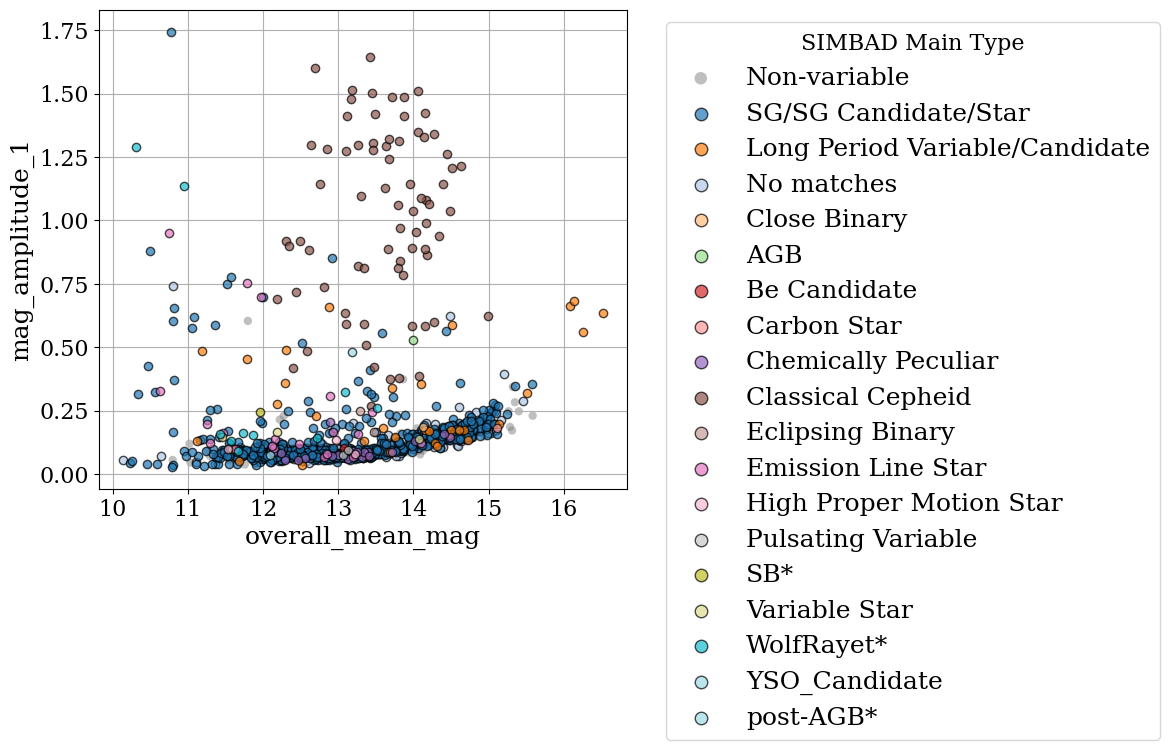

In [9]:
def plot_simbad_crossmatch_tidy(xcol, ycol):
    """ Plot the SIMBAD crossmatch data, grouping specified main_types under a single color, and plotting missing main_type as 'Unknown'.
    """
    # plt.figure(figsize=(16, 8))
    plt.figure(figsize=(12,7))
    # Treat empty strings and nan as 'Unknown'
    main_types = stats['SIMBAD_maintype'].replace('', np.nan).fillna('Unknown').astype(str)
    # Groups stars, SGs, and candidates together
    grouped_types = set([
        'Star', 'RedSG_Candidate', 'YellowSG', 'RedSG', 'Supergiant',
        'BlueSG', 'YellowSG_Candidate', 'Supergiant_Candidate', 'BlueSG_Candidate'
    ])
    LPV_grouped_types = set(['LongPeriodV*', 'LongPeriodV*_Candidate'])
    is_LPV_grouped = main_types.isin(LPV_grouped_types)
    is_grouped = main_types.isin(grouped_types)
    is_unknown = main_types == 'Unknown'
    other_types = sorted(set(main_types.unique()) - grouped_types - {'Unknown'} - LPV_grouped_types)
    # cmap = cm.get_cmap('nipy_spectral', max(3, len(other_types) + 2))
    cmap = cm.get_cmap('tab20', max(3, len(other_types) + 2))
    grouped_color = cmap(0)
    unknown_color = cmap(1)
    LPV_color = cmap(2)
    other_colors = [cmap(i + 3) for i in range(len(other_types))]

    var_mask = (stats['alarm_level_flag'] == 0).values
    nonvar_mask = (stats['alarm_level_flag'] == 1).values
    # Plot nonvariable stars in gray 
    plt.scatter(stats[xcol][nonvar_mask],stats[ycol][nonvar_mask],
                color='gray', alpha=0.5, edgecolors='none', label='Non-variable', zorder=1)
    # Plot grouped types
    plt.scatter(stats[xcol][var_mask][is_grouped[var_mask]],
                stats[ycol][var_mask][is_grouped[var_mask]],
                label='SG/SG Candidate/Star', color=grouped_color, alpha=0.7, edgecolors='black', zorder=3)
    # Plot LPV grouped types
    plt.scatter(stats[xcol][var_mask][is_LPV_grouped[var_mask]],
                stats[ycol][var_mask][is_LPV_grouped[var_mask]],
                label='Long Period Variable/Candidate', color=LPV_color, alpha=0.7, edgecolors='black', zorder=4)
    # Plot unknown types (missing main_type)
    plt.scatter(stats[xcol][var_mask][is_unknown[var_mask]],
                stats[ycol][var_mask][is_unknown[var_mask]],
                label='No matches', color=unknown_color, alpha=0.7, edgecolors='black', zorder=2)
    # # Plot other types
    for i, t in enumerate(other_types):
        mask = (main_types == t)
        # Plot variable stars of this type
        var_type_mask = var_mask & mask
        if var_type_mask.any():
            if t == 'ChemPec*':
                t = 'Chemically Peculiar'
            if t == 'Be*_Candidate':
                t = 'Be Candidate'
            if t == '**':
                t = 'Close Binary'
            if t == 'C*':
                t = 'Carbon Star'
            if t == 'AGB*':
                t = 'AGB'
            if t == 'ClassicalCep':
                t = 'Classical Cepheid'
            if t == 'EclBin':
                t = 'Eclipsing Binary'
            if t == 'EmLine*':
                t = 'Emission Line Star'
            if t == 'HighPM*':
                t = 'High Proper Motion Star'
            # if t == 'LongPeriodV*' or t == 'LongPeriodV*_Candidate':
            #     t = 'Long Period Variable/Candidate'
            if t == 'PulsV*':
                t = 'Pulsating Variable'
            if t == 'Variable*':
                t = 'Variable Star'
            plt.scatter(stats[xcol][var_type_mask], stats[ycol][var_type_mask],
                        label=f'{t}', color=other_colors[i], alpha=0.7, edgecolors='black', zorder=5)
    # # Plot non-variable stars of this type
    # nonvar_type_mask = nonvar_mask & mask
    # if nonvar_type_mask.any():
    #     plt.scatter(stats[xcol][nonvar_type_mask], stats[ycol][nonvar_type_mask],
    #                 label=f'{t} (Non-variable)', color=other_colors[i], alpha=0.5, edgecolors='none')
    plt.xlabel(xcol, fontsize=18)
    plt.ylabel(ycol, fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.legend(title='SIMBAD Main Type', bbox_to_anchor=(1.05, 1), loc='upper left', title_fontsize=16, fontsize=18, markerscale=1.5)
    plt.grid(True, zorder=0)
    plt.tight_layout()
    plt.savefig(f'hr_diagrams/simbad_crossmatch_{xcol}_{ycol}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
plot_simbad_crossmatch_tidy('overall_mean_mag', 'mag_amplitude_1')

/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_26385/3285131548.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('nipy_spectral', max(3, len(other_types) + 2))


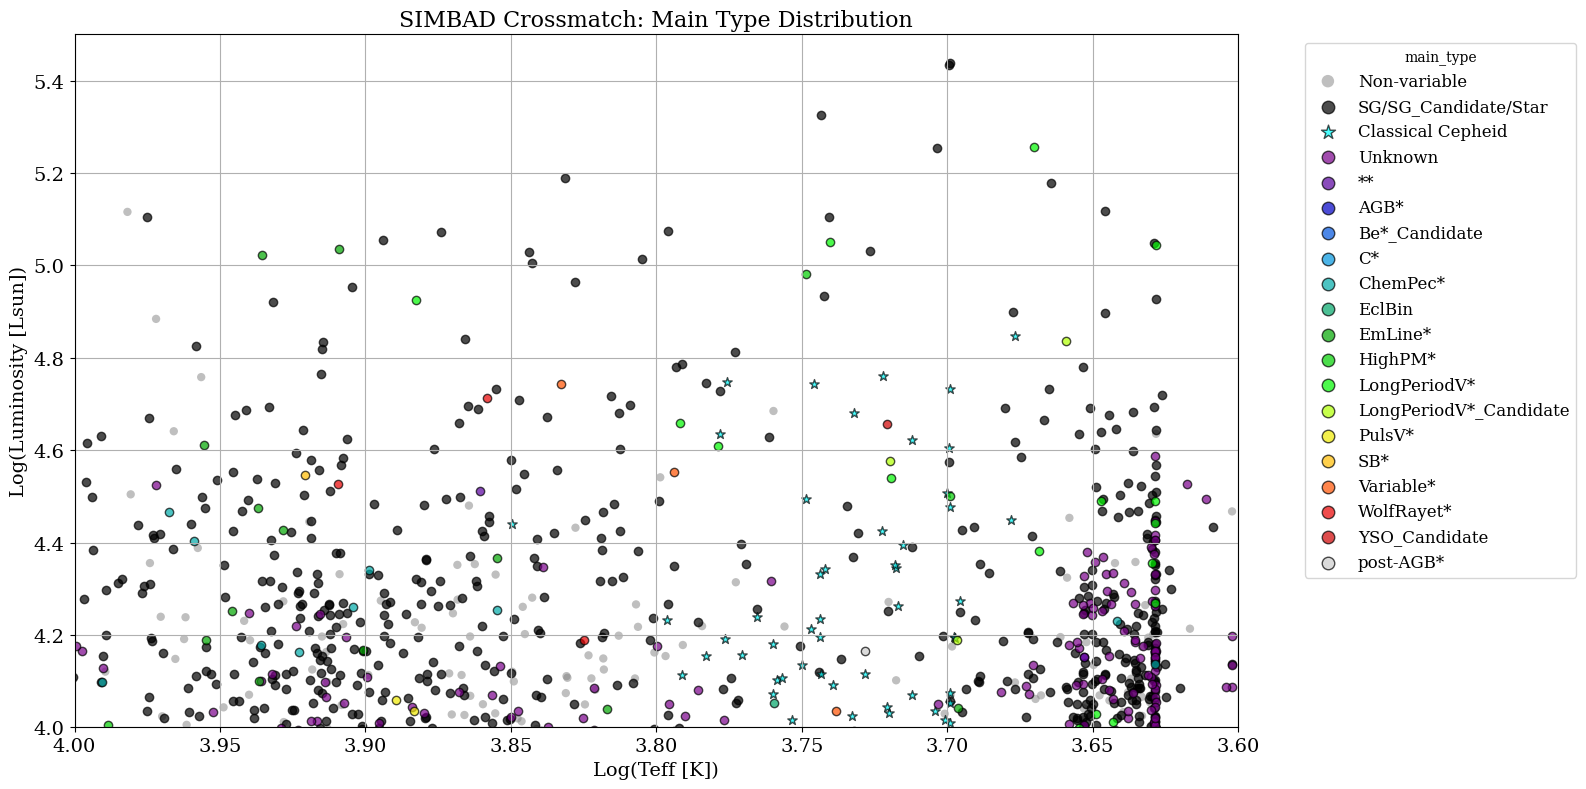

In [10]:
def plot_simbad_HRD(xcol, ycol):
    """ Plot the SIMBAD crossmatch data, grouping specified main_types under a single color, and plotting missing main_type as 'Unknown'.
    """
    plt.figure(figsize=(16, 8))
    # plt.figure(figsize=(10,7))
    # Treat empty strings and nan as 'Unknown'
    main_types = stats['SIMBAD_maintype'].replace('', np.nan).fillna('Unknown').astype(str)
    # Groups stars, SGs, and candidates together
    grouped_types = set([
        'Star', 'RedSG_Candidate', 'YellowSG', 'RedSG', 'Supergiant',
        'BlueSG', 'YellowSG_Candidate', 'Supergiant_Candidate', 'BlueSG_Candidate'
    ])
    cephs_grouped_types = set(['ClassicalCep', 'ClassicalCep'])
    is_grouped = main_types.isin(grouped_types)
    is_cephs = main_types.isin(cephs_grouped_types)
    is_unknown = main_types == 'Unknown'
    other_types = sorted(set(main_types.unique()) - grouped_types - cephs_grouped_types - {'Unknown'})
    cmap = cm.get_cmap('nipy_spectral', max(3, len(other_types) + 2))
    grouped_color = cmap(0)
    unknown_color = cmap(1)
    cephs_color = 'cyan'
    other_colors = [cmap(i + 2) for i in range(len(other_types))]

    var_mask = (stats['alarm_level_flag'] == 0).values
    nonvar_mask = (stats['alarm_level_flag'] == 1).values
    # Plot nonvariable stars in gray 
    plt.scatter(stats[xcol][nonvar_mask],stats[ycol][nonvar_mask],
                color='gray', alpha=0.5, edgecolors='none', label='Non-variable')
    # Plot grouped types
    plt.scatter(stats[xcol][var_mask][is_grouped[var_mask]],
                stats[ycol][var_mask][is_grouped[var_mask]],
                label='SG/SG_Candidate/Star', color=grouped_color, alpha=0.7, edgecolors='black')
    # Plot cepheids with a star
    plt.scatter(stats[xcol][var_mask][is_cephs[var_mask]],
                stats[ycol][var_mask][is_cephs[var_mask]],
                label='Classical Cepheid', color=cephs_color, alpha=0.7, marker='*', s=50, edgecolors='black')

    # Plot unknown types (missing main_type)
    plt.scatter(stats[xcol][var_mask][is_unknown[var_mask]],
                stats[ycol][var_mask][is_unknown[var_mask]],
                label='Unknown', color=unknown_color, alpha=0.7, edgecolors='black')
    # # Plot other types
    for i, t in enumerate(other_types):
        mask = (main_types == t)
        # Plot variable stars of this type
        var_type_mask = var_mask & mask
        if var_type_mask.any():
            plt.scatter(stats[xcol][var_type_mask], stats[ycol][var_type_mask],
                        label=f'{t}', color=other_colors[i], alpha=0.7, edgecolors='black')
    # # Plot non-variable stars of this type
    # nonvar_type_mask = nonvar_mask & mask
    # if nonvar_type_mask.any():
    #     plt.scatter(stats[xcol][nonvar_type_mask], stats[ycol][nonvar_type_mask],
    #                 label=f'{t} (Non-variable)', color=other_colors[i], alpha=0.5, edgecolors='none')
    plt.xlabel(xcol, fontsize=14)
    plt.ylabel(ycol, fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('Log(Teff [K])', fontsize=14)
    # plt.xlabel('Mean Magnitude (g)', fontsize=14)
    plt.ylabel('Log(Luminosity [Lsun])', fontsize=14)
    plt.title('SIMBAD Crossmatch: Main Type Distribution', fontsize=16)
    plt.legend(title='main_type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, markerscale=1.5)
    plt.grid(True)
    plt.tight_layout()
    plt.xlim(3.6,4.0)
    plt.ylim(4.0,5.5)

    plt.gca().invert_xaxis()
    plt.savefig(f'hr_diagrams/simbad_HRD_{xcol}_{ycol}.pdf', dpi=300, bbox_inches='tight')
    plt.show()
plot_simbad_HRD('logT', 'logL')

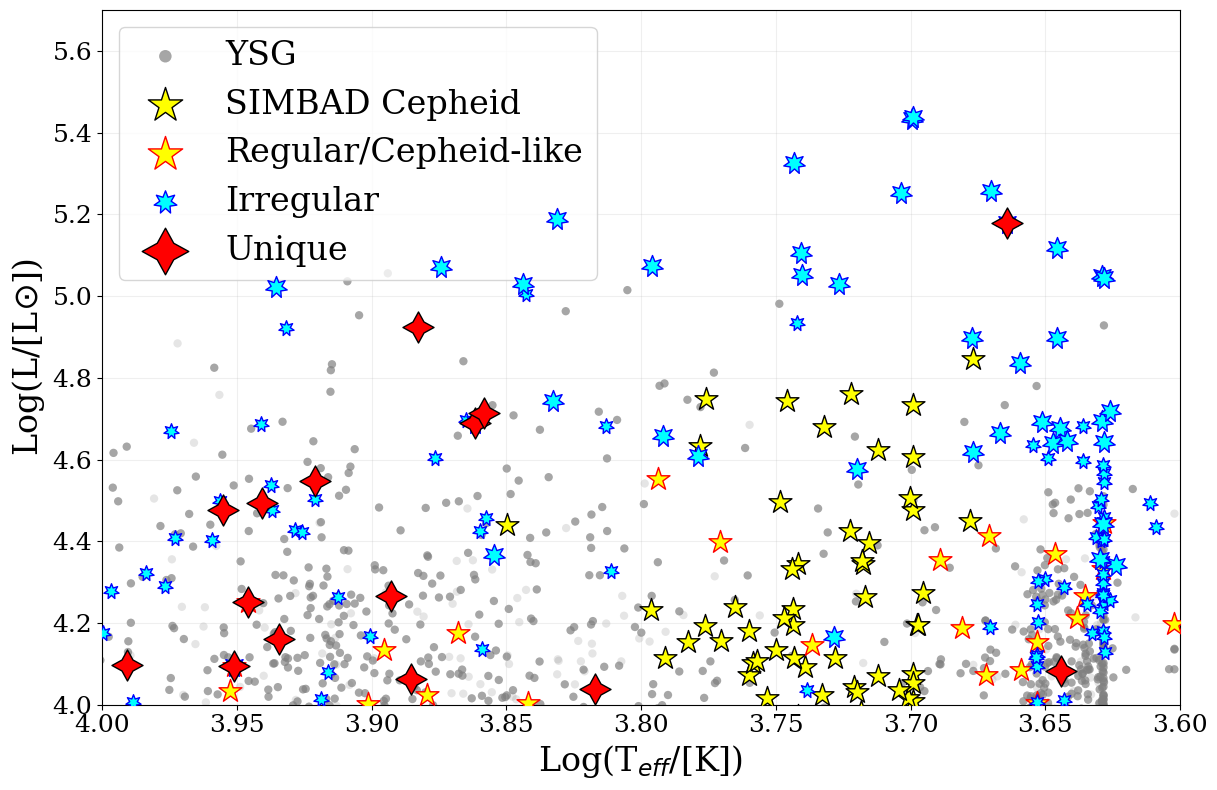

In [11]:
def plot_interesting_HRD(xcol, ycol):
    plt.figure(figsize=(12, 8))
    main_types = stats['SIMBAD_maintype'].replace('', np.nan).fillna('Unknown').astype(str)
    cephs_grouped_types = set(['ClassicalCep', 'ClassicalCep'])
    # identify 
    cephs = hrd_zoning[hrd_zoning['cepheid_like'] == 1]
    large_spikes = hrd_zoning[hrd_zoning['large_spikes'] == 1]
    eb = hrd_zoning[hrd_zoning['eclipsing_binary_cands'] == 1]
    irregular = hrd_zoning[hrd_zoning['spikes_irregular'] == 1]
    very_high_p = hrd_zoning[(hrd_zoning['priority']=='very_high')]
    long_period = hrd_zoning[hrd_zoning['long_period'] == 1]
    high_p_mask = hrd_zoning[hrd_zoning['priority']=='high']
    ##### high priority masks
    cephs_high = cephs[cephs['priority'] == 'high']
    cephs_very_high = cephs[cephs['priority'] == 'very_high']
    large_spikes_high = large_spikes[large_spikes['priority'] == 'high']
    eb_high = eb[eb['priority'] == 'high']
    very_high_p_high = very_high_p[very_high_p['priority'] == 'high']
    long_period_high = long_period[long_period['priority'] == 'high']
    high_p_irregular = hrd_zoning[(hrd_zoning['priority']=='high') & (hrd_zoning['spikes_irregular'] == 1)]
    very_high_p_irregular = hrd_zoning[(hrd_zoning['priority']=='very_high') & (hrd_zoning['spikes_irregular'] == 1)]
    very_high_p_long_period = hrd_zoning[(hrd_zoning['priority']=='very_high') & (hrd_zoning['long_period'] == 1)]

    is_cephs = main_types.isin(cephs_grouped_types)
    # is_lpv = main_types.isin(lpv)
    # is_pulsV = main_types.isin(pulsV)
    cephs_color = 'yellow'
    non_ceph_mask = ~is_cephs
    # non_lpv_mask = ~is_lpv
    # non_pulsV_mask = ~is_pulsV
    T_mask = (stats['logT'] > 3.6) & (stats['logT'] < 4.0)
    L_mask = stats['logL'] > 4.0

    var_mask = (stats['alarm_level_flag'] == 0).values
    nonvar_mask = (stats['alarm_level_flag'] == 1).values
    # Build exclusion list from tagged groups and remove them from periodic stars.
    # tagged_groups = [cephs, large_spikes, eb, irregular, very_high_p, long_period]
    tagged_groups = [cephs]
    exclude_ids = pd.Index([])
    for group in tagged_groups:
        if 'star_idx' in group.columns:
             exclude_ids = exclude_ids.union(group['star_idx'].dropna().astype(int))
        else:
             exclude_ids = exclude_ids.union(group.index)
                
    if 'star_idx' in stats.columns:
        var_mask = (stats['alarm_level_flag'] == 0) & (~stats['star_idx'].isin(exclude_ids))
    else:
        var_mask = (stats['alarm_level_flag'] == 0) & (~stats.index.isin(exclude_ids))
    # Plot nonvariable stars in gray 
    plt.scatter(stats[xcol][nonvar_mask],stats[ycol][nonvar_mask],
                color='gray', alpha=0.2, edgecolors='none')
    # Plot variable stars that are not cepheids in gray
    # plt.scatter(stats[xcol][var_mask][non_ceph_mask[var_mask]],
    #             stats[ycol][var_mask][non_ceph_mask[var_mask]],
    #              color='gray', alpha=0.4, edgecolors='none', label='YSG')
    plt.scatter(stats[xcol][var_mask],
                stats[ycol][var_mask],
                 color='gray', alpha=0.7, edgecolors='none', label='YSG')

    # SIMBAD #############
    # alpha = 0.2
    alpha = 1.0
    plt.scatter(stats[xcol][is_cephs],stats[ycol][is_cephs],
                label='SIMBAD Cepheid', color=cephs_color, alpha=1.0, marker='*', s=300, edgecolors='black', zorder = 10)
    plt.scatter(cephs[xcol],cephs[ycol],
            label='Regular/Cepheid-like', color='yellow', alpha=alpha, marker='*', s=300, edgecolors='red', zorder = 10)
    plt.scatter(irregular[xcol],
            irregular[ycol], label='Irregular', color='cyan', alpha=alpha, marker=sevenpointstar, s=125, edgecolors='blue', zorder = 10)
    plt.scatter(large_spikes[xcol], #label='Large Spikes',
            large_spikes[ycol], color='cyan', alpha=alpha, marker=sevenpointstar, s=250, edgecolors='blue', zorder = 10)
    # plt.scatter(eb[xcol],
    #         eb[ycol], label='Eclipsing Binary', color='magenta', alpha=alpha, marker='X', s=250, edgecolors='black', zorder = 10)
    # plt.scatter(long_period[xcol],
    #             long_period[ycol], label='Long Period Trend', color='purple', alpha=alpha, marker='D', s=50, edgecolors='black', zorder = 11)
    plt.scatter(very_high_p[xcol],
                very_high_p[ycol], label='Unique', color='red', alpha=1.0, marker=fourpointstar, s=500, edgecolors='black', zorder = 12)
    #### masked by high priority
    # plt.scatter(cephs_high[xcol],
    #             cephs_high[ycol], label='High Priority Cepheid-like', color='yellow', alpha=1.0, marker='*', s=300, edgecolors='red', zorder = 10)
    # plt.scatter(high_p_irregular[xcol],
    #             high_p_irregular[ycol], label='High Priority Irregular', color='cyan', alpha=1.0, marker=sevenpointstar, s=125, edgecolors='red', zorder = 10)
    # plt.scatter(large_spikes_high[xcol], #label='Large Spikes',
    #             large_spikes_high[ycol], color='cyan', alpha=1.0, marker=sevenpointstar, s=250, edgecolors='red', zorder = 10)
#     plt.scatter(very_high_p_irregular[xcol],
#                 very_high_p_irregular[ycol], label='Very High Priority Irregular', color='red', alpha=1.0, marker=fourpointstar, s=400, edgecolors='black', zorder = 11)
    # plt.scatter(long_period_high[xcol],
    #             long_period_high[ycol], label='High Priority Long Trend', color='purple', alpha=1.0, marker='D', s=50, edgecolors='red', zorder = 11)
#     plt.scatter(very_high_p_long_period[xcol],
#                 very_high_p_long_period[ycol], label='Very High Priority Long Period',  color='red', alpha=1.0, marker=fourpointstar, s=300, edgecolors='black', zorder = 11)
    

    # plt.xlabel(xcol, fontsize=22)
    # plt.ylabel(ycol, fontsize=22)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('Log(T$_{eff}$/[K])', fontsize=24)
    # plt.xlabel('Mean Magnitude (g)', fontsize=22)
    plt.ylabel('Log(L/[L$\\odot$])', fontsize=24)
    # plt.title('SIMBAD Crossmatch: Main Type Distribution', fontsize=16)
    plt.legend(loc='upper left', fontsize=24, markerscale=1.5) # 24
    # pin legend to side
    # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=18, markerscale=1.5)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.xlim(3.6,4.0)
    plt.ylim(4.0,5.7)

    plt.gca().invert_xaxis()
    plt.savefig(f'hr_diagrams/_HRD_{xcol}_{ycol}.png', dpi=300, bbox_inches='tight')
    plt.show()
plot_interesting_HRD('logT', 'logL')

In [12]:
def plot_interesting_HRD_animated(xcol, ycol, frames=120, interval=60):
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML, display

    fig, ax = plt.subplots(figsize=(10, 8))

    main_types = stats['SIMBAD_maintype'].replace('', np.nan).fillna('Unknown').astype(str)
    cephs_grouped_types = {'ClassicalCep'}

    # Identify groups
    high_p_cephs = hrd_zoning[hrd_zoning['cepheid_like'] == 1]
    large_spikes = hrd_zoning[hrd_zoning['large_spikes'] == 1]
    very_high_p = hrd_zoning[hrd_zoning['priority'] == 'very_high']
    high_p = hrd_zoning[hrd_zoning['priority'] == 'high']
    is_cephs = main_types.isin(cephs_grouped_types)
    non_ceph_mask = ~is_cephs
    cephs_color = 'yellow'

    var_mask = (stats['alarm_level_flag'] == 0).values
    nonvar_mask = (stats['alarm_level_flag'] == 1).values

    # Static background points
    ax.scatter(
        stats[xcol][nonvar_mask],
        stats[ycol][nonvar_mask],
        color='gray',
        alpha=0.2,
        edgecolors='none'
    )
    ax.scatter(
        stats[xcol][var_mask][non_ceph_mask[var_mask]],
        stats[ycol][var_mask][non_ceph_mask[var_mask]],
        color='gray',
        alpha=0.2,
        edgecolors='none',
        label='YSG'
    )

    # Foreground points to animate (pulse marker size)
    sc_ceph = ax.scatter(
        stats[xcol][var_mask][is_cephs[var_mask]],
        stats[ycol][var_mask][is_cephs[var_mask]],
        label='Classical Cepheid',
        color=cephs_color,
        alpha=0.4,
        marker='*',
        s=250,
        edgecolors='black',
        zorder=10
    )
    sc_regular = ax.scatter(
        high_p_cephs[xcol],
        high_p_cephs[ycol],
        label='Periodic radial pulsators',
        color='yellow',
        alpha=1.0,
        marker='*',
        s=250,
        edgecolors='black',
        zorder=10
    )
    sc_irregular = ax.scatter(
        large_spikes[xcol],
        large_spikes[ycol],
        label='Semi-regular pulsators',
        color='cyan',
        alpha=1.0,
        marker=sevenpointstar,
        s=250,
        edgecolors='black',
        zorder=10
    )
    # sc_identified = ax.scatter(
    #     very_high_p[xcol],
    #     very_high_p[ycol],
    #     label='Identified',
    #     color='red',
    #     alpha=1.0,
    #     marker=fourpointstar,
    #     s=300,
    #     edgecolors='black',
    #     zorder=8
    # )
    # sc_highp = ax.scatter(
    #     high_p[xcol],
    #     high_p[ycol],
    #     label='High Priority',
    #     color='magenta',
    #     alpha=1.0,
    #     marker='X',
    #     s=250,
    #     edgecolors='black',
    #     zorder=10
    # )

    # fill between
    # ax.fill_between([3.85,3.50], [2.0, 5.6], [4.0, 7.6], color='mediumpurple', alpha=0.2, zorder=0)
    ax.tick_params(axis='both', labelsize=18)
    ax.set_xlabel('Log(T$_{eff}$/[K])', fontsize=24)
    ax.set_ylabel('Log(L/[L$\\odot$])', fontsize=24)
    ax.legend(loc='upper left', fontsize=24, markerscale=1.5)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(3.6, 4.0)
    ax.set_ylim(4.0, 5.8)
    ax.invert_xaxis()
    fig.tight_layout()

    # # artists = [sc_ceph, sc_regular, sc_irregular, sc_identified]
    # base_sizes = np.array([300.0, 300.0, 250.0, 300.0])
    # amplitudes = np.array([75.0, 50.0, 25.0, 100.0])
    # phases = np.array([0.0, 0.0, 2.0 * np.pi / 3.0, np.pi / 2.0])

    # artists = [sc_ceph, sc_regular]
    # base_sizes = base_sizes[:2]
    # amplitudes = amplitudes[:2]
    # phases = phases[:2]

    # def update(frame):
    #     t = 2.0 * np.pi * frame / frames
    #     sizes = base_sizes - amplitudes * (1. + 3 * np.sin(t + phases))
    #     for artist, size in zip(artists, sizes):
    #         n = len(artist.get_offsets())
    #         if n > 0:
    #             artist.set_sizes(np.full(n, size))
    #     return artists

    # anim = FuncAnimation(fig, update, frames=frames, interval=interval, blit=False, repeat=True)
    # display(HTML(anim.to_jshtml()))
    # plt.close(fig)
    # return anim

# plot_interesting_HRD_animated('logT', 'logL')

In [13]:
def plot_amp_vs_nearest_cepheid_distance(x_hr='logT',y_hr='logL',amp_col='mag_amplitude_1',show_nonperiodic=False,save_path=None,):
    # Build a working table aligned between stats and hrd_zoning.
    if 'star_idx' in stats.columns and 'star_idx' in hrd_zoning.columns:
        base = stats[['star_idx', x_hr, y_hr, amp_col, 'SIMBAD_maintype', 'alarm_level_flag']].merge(
            hrd_zoning[['star_idx', 'spikes_irregular', 'priority', 'regular_spikes', 'two_dips', 'large_spikes']],on='star_idx',how='left')
    else:
        base = stats[[x_hr, y_hr, amp_col, 'SIMBAD_maintype', 'alarm_level_flag']].copy()
        base['spikes_irregular'] = hrd_zoning['spikes_irregular'].values
        base['priority'] = hrd_zoning['priority'].values
        base['star_idx'] = base.index

    # Cepheid reference set from SIMBAD main type.
    cepheids = base[base['SIMBAD_maintype'] == 'ClassicalCep'][[x_hr, y_hr]].dropna()
    candidates = base.dropna(subset=[x_hr, y_hr, amp_col]).copy()
    cand_xy = candidates[[x_hr, y_hr]].to_numpy(dtype=float)
    ceph_xy = cepheids[[x_hr, y_hr]].to_numpy(dtype=float)

    d2 = ((cand_xy[:, None, :] - ceph_xy[None, :, :]) ** 2).sum(axis=2)
    candidates['nearest_cepheid_dist'] = np.sqrt(d2.min(axis=1))

    irregular_mask = candidates['spikes_irregular'] == 1
    very_high_mask = candidates['priority'] == 'very_high'
    regular_mask = candidates['regular_spikes'] == 1
    two_dips_mask = candidates['two_dips'] == 1
    large_spikes_mask = candidates['large_spikes'] == 1

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(candidates.loc[irregular_mask, 'nearest_cepheid_dist'],candidates.loc[irregular_mask, amp_col],color='cyan', edgecolors='black', alpha=0.85,s=70,label='Irregular',zorder=3)
    ax.scatter(candidates.loc[very_high_mask, 'nearest_cepheid_dist'],candidates.loc[very_high_mask, amp_col],color='red',edgecolors='black',alpha=0.9,marker='*',s=180,label='Very High Priority',zorder=4)
    ax.scatter(candidates.loc[regular_mask, 'nearest_cepheid_dist'],candidates.loc[regular_mask, amp_col],color='orange',edgecolors='black',alpha=0.85,marker='*',s=120,label='Regular',zorder=4)
    ax.scatter(candidates.loc[two_dips_mask, 'nearest_cepheid_dist'],candidates.loc[two_dips_mask, amp_col],color='magenta',edgecolors='black',alpha=0.85,marker='X',s=120,label='Two Dips',zorder=4)
    ax.scatter(candidates.loc[large_spikes_mask, 'nearest_cepheid_dist'],candidates.loc[large_spikes_mask, amp_col],color='cyan',edgecolors='black',alpha=0.85,marker=sevenpointstar,s=120,label='Large Spikes',zorder=4)
    # Label each plotted star with its star_idx.
    plotted = candidates.loc[irregular_mask | very_high_mask].copy()
    plotted = plotted.drop_duplicates(subset=['star_idx'])
    for _, row in plotted.iterrows():
        ax.annotate(
            str(int(row['star_idx'])),
            (row['nearest_cepheid_dist'], row[amp_col]),
            textcoords='offset points',
            xytext=(0, 5),
            ha='center',
            va='bottom',
            fontsize=8,
            color='black',
            zorder=6,
        )
    ax.set_xlabel('Distance to nearest Classical Cepheid in HR space', fontsize=16)
    ax.set_ylabel(f'{amp_col}', fontsize=16)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=13)
    ax.legend(fontsize=13)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
# plot_amp_vs_nearest_cepheid_distance(save_path='hr_diagrams/amp_vs_cepheid_distance.pdf')

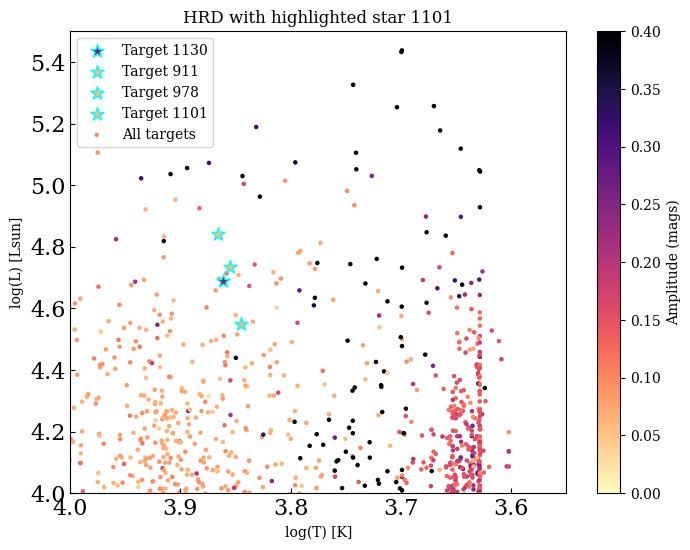

In [14]:
def HR_highlight(index):
    fig = plt.figure(figsize=(8, 6))
    min= 0
    max = 0.4
    # box =  [307,286,756, 1189] #1168
    box = [1130,911,978, 1101]
# box3 = [716,541,579,1100]
    # norm = LogNorm(vmin=min, vmax=max)
    variable_mask = (var['alarm_level_flag']== 0)
    for index in box:
        plt.scatter(var.loc[index, 'logT'], var.loc[index, 'logL'], c =var.loc[index, 'mag_amplitude_1'], cmap='magma_r', marker='*', s=100, edgecolors='cyan', label=f'Target {index}', vmin = min, vmax = max, zorder=10)
    plt.scatter(var['logT'][variable_mask], var['logL'][variable_mask], c =var['mag_amplitude_1'][variable_mask],  cmap='magma_r', marker='o', s=5, label='All targets', vmin = min, vmax = max)
    plt.colorbar(label='Amplitude (mags)')
    plt.xlim(3.55, 4.0)
    plt.ylim(4.0,5.5)
    plt.gca().invert_xaxis()
    plt.tick_params(axis='both', which='both', direction = 'in', labelsize=16)
    plt.xlabel('log(T) [K]')
    plt.ylabel('log(L) [Lsun]')
    plt.title(f'HRD with highlighted star {index}')
    plt.legend()
    plt.show()

HR_highlight(3)

# Looking at each star

In [15]:
############ priority lists ############
very_high_priority = [216, 322, 420, 537, 539, 770, 771, 780, 826, 864, 1025, 1034, 1057, 1130, 1182]
print(f'very high priority: {len(very_high_priority)} stars')
high_priority = [10, 14, 55, 65, 66, 68, 77, 81, 86, 91, 96, 105, 114, 115, 156, 172, 198, 213, 218, 225, 250, 307, 308, 347, 395, 403, 412, 414, 444, 495, 534, 584, 585, 590, 596, 597, 602, 613, 641, 665, 689, 697, 716, 720, 725, 729, 741, 744, 746, 762, 763, 773, 785, 790, 829, 834, 839, 840, 849, 851, 856, 857, 866, 877, 882, 889, 890, 902, 914, 931, 936, 946, 953, 961, 965, 998, 1011, 1020, 1028, 1029, 1037, 1051, 1055, 1056, 1058, 1068, 1079, 1085, 1087, 1092, 1094, 1095, 1102, 1103, 1111, 1115, 1117, 1120, 1131, 1152, 1166, 1167, 1174, 1183, 1187, 1194, 1195, 1201, 1203, 1204, 1211, 1212, 1213, 1252, 1253, 1259, 1261]
print(f'high priority: {len(high_priority)} stars')
medium_priority = [39, 40, 59, 89, 95, 106, 119, 142, 151, 163, 205, 241, 245, 246, 249, 254, 258, 265, 283, 287, 288, 291, 292, 296, 297, 301, 303, 305, 306, 310, 318, 321, 325, 326, 329, 332, 335, 338, 340, 345, 348, 351, 352, 353, 354, 355, 357, 359, 360, 361, 363, 365, 368, 370, 372, 373, 377, 378, 380, 381, 386, 392, 398, 399, 404, 410, 411, 415, 419, 421, 422, 423, 428, 429, 432, 442, 443, 445, 447, 448, 450, 455, 471, 475, 482, 487, 498, 501, 503, 504, 506, 507, 508, 509, 512, 513, 514, 515, 522, 528, 530, 536, 541, 543, 551, 552, 553, 555, 556, 558, 562, 565, 566, 568, 570, 575, 579, 588, 593, 598, 604, 608, 609, 611, 614, 626, 635, 637, 654, 658, 673, 675, 676, 682, 690, 691, 695, 699, 701, 707, 708, 711, 712, 713, 714, 715, 717, 722, 723, 726, 728, 739, 743, 745, 748, 749, 752, 755, 757, 758, 759, 761, 765, 766, 769, 772, 775, 776, 791, 801, 803, 810, 814, 822, 835, 841, 854, 859, 860, 863, 881, 897, 904, 905, 910, 913, 926, 927, 929, 941, 943, 944, 945, 949, 954, 956, 957, 958, 963, 970, 987, 988, 995, 1002, 1007, 1009, 1030, 1031, 1035, 1047, 1052, 1067, 1138, 1161, 1169, 1197, 1198, 1199, 1214, 1215, 1223, 1230, 1233, 1238, 1239, 1240, 1243, 1246, 1262, 1269]
print(f'medium priority: {len(medium_priority)} stars')
low_priority = [0, 3, 5, 9, 11, 13, 15, 18, 20, 21, 25, 28, 30, 31, 33, 34, 37, 38, 46, 47, 48, 49, 51, 52, 53, 56, 57, 58, 61, 63, 64, 67, 76, 80, 82, 83, 84, 85, 87, 97, 98, 101, 103, 109, 111, 112, 116, 117, 118, 120, 121, 123, 124, 125, 127, 128, 129, 130, 131, 132, 134, 136, 137, 138, 141, 145, 146, 149, 155, 159, 161, 164, 166, 168, 170, 180, 181, 186, 192, 194, 195, 196, 197, 199, 202, 206, 208, 211, 212, 214, 215, 219, 220, 221, 222, 223, 224, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 238, 239, 248, 251, 253, 255, 256, 257, 262, 264, 266, 267, 268, 270, 273, 274, 275, 276, 277, 278, 280, 289, 290, 293, 300, 314, 319, 342, 356, 362, 364, 367, 376, 387, 405, 407, 437, 439, 452, 454, 458, 464, 467, 488, 489, 490, 519, 523, 532, 542, 544, 549, 554, 560, 561, 573, 610, 621, 627, 628, 629, 632, 639, 643, 647, 659, 660, 661, 670, 672, 678, 679, 680, 683, 684, 692, 693, 698, 706, 710, 718, 731, 733, 753, 756, 782, 799, 805, 806, 807, 808, 809, 815, 816, 820, 827, 828, 830, 833, 837, 838, 844, 850, 858, 865, 871, 874, 875, 878, 879, 880, 885, 887, 891, 893, 894, 896, 898, 901, 908, 909, 911, 912, 915, 916, 917, 918, 919, 920, 921, 924, 925, 928, 930, 933, 938, 940, 942, 947, 948, 952, 959, 964, 968, 969, 972, 973, 977, 978, 981, 986, 989, 991, 992, 993, 994, 996, 1001, 1003, 1004, 1006, 1008, 1010, 1022, 1038, 1039, 1060, 1066, 1075, 1084, 1086, 1088, 1091, 1093, 1100, 1101, 1109, 1110, 1116, 1119, 1123, 1124, 1128, 1135, 1160, 1168, 1176, 1177, 1178, 1189, 1202, 1208, 1210, 1216, 1225, 1226, 1229, 1231, 1250, 1254, 1265]
print(f'low priority: {len(low_priority)} stars')
green_selected = [307, 1130, 613, 1085, 716, 953, 250, 890, 156, 40, 241, 780, 522]

very high priority: 15 stars
high priority: 117 stars
medium priority: 230 stars
low priority: 308 stars


In [16]:
############### hr zones ###############
RSG = [0, 3, 5, 9, 10, 11, 13, 15, 18, 20, 21, 25, 29, 30, 39, 40, 46, 47, 52, 53, 55, 57, 58, 59, 63, 64, 66, 67, 68, 75, 77, 83, 85, 86, 89, 91, 95, 96, 97, 98, 103, 106, 109, 112, 114, 115, 117, 118, 120, 124, 125, 127, 128, 129, 130, 131, 132, 134, 138, 141, 142, 145, 146, 151, 156, 159, 161, 164, 166, 168, 172, 181, 186, 192, 195, 198, 205, 208, 211, 212, 214, 215, 219, 222, 223, 224, 225, 226, 227, 228, 230, 231, 233, 234, 235, 239, 245, 248, 249, 253, 255, 256, 258, 262, 264, 265, 267, 270, 273, 274, 275, 276, 287, 288, 290, 291, 292, 297, 300, 303, 305, 308, 314, 321, 326, 329, 332, 335, 338, 340, 345, 348, 351, 352, 353, 356, 357, 360, 361, 362, 364, 367, 368, 370, 373, 376, 380, 392, 467, 482, 503, 512, 515, 536, 553, 565, 566, 575, 584, 588, 598, 610, 611, 632, 635, 637, 639, 654, 665, 680, 682, 683, 684, 689, 691, 701, 708, 717, 729, 739, 745, 746, 755, 814, 815, 826, 829, 833, 837, 838, 840, 844, 849, 851, 856, 863, 878, 881, 887, 891, 893, 894, 901, 905, 908, 910, 912, 913, 914, 915, 916, 918, 919, 920, 921, 924, 927, 933, 938, 940, 941, 942, 944, 945, 948, 949, 952, 954, 956, 957, 963, 968, 969, 970, 972, 973, 986, 987, 988, 989, 991, 993, 994, 995, 996, 1002, 1003, 1004, 1007, 1009, 1035, 1056, 1068, 1169, 1211, 1230]
print(f'RSGs: {len(RSG)} stars')
instability_strip = [14, 37, 38, 65, 80, 105, 238, 250, 318, 347, 363, 395, 411, 419, 455, 471, 487, 506, 508, 534, 541, 561, 562, 573, 579, 596, 613, 641, 658, 659, 679, 693, 695, 698, 710, 716, 776, 782, 810, 834, 864, 865, 871, 874, 875, 882, 885, 890, 898, 902, 904, 917, 928, 930, 936, 946, 953, 961, 992, 1001, 1006, 1011, 1020, 1022, 1028, 1029, 1030, 1038, 1039, 1051, 1055, 1075, 1079, 1085, 1091, 1093, 1094, 1095, 1100, 1102, 1109, 1115, 1120, 1124, 1187, 1201, 1203, 1213, 1216, 1225, 1226, 1233, 1240, 1253, 1259, 1261, 1265]
print(f'Instability strip: {len(instability_strip)} stars')
hot_dim = [31, 33, 34, 49, 51, 56, 61, 81, 82, 84, 87, 101, 116, 121, 123, 136, 137, 155, 163, 170, 180, 196, 197, 199, 202, 206, 213, 216, 218, 221, 229, 232, 241, 246, 251, 257, 266, 268, 277, 278, 280, 289, 293, 296, 301, 307, 310, 319, 322, 325, 354, 355, 359, 365, 372, 377, 378, 381, 386, 387, 398, 399, 404, 405, 407, 410, 412, 415, 421, 422, 423, 428, 429, 432, 437, 439, 442, 443, 444, 445, 447, 448, 450, 452, 454, 458, 464, 475, 488, 489, 490, 495, 498, 501, 504, 507, 509, 513, 514, 519, 523, 528, 530, 532, 537, 542, 543, 544, 549, 551, 552, 554, 555, 556, 558, 560, 568, 570, 585, 604, 608, 609, 614, 621, 626, 627, 628, 629, 643, 647, 660, 661, 670, 672, 673, 675, 676, 678, 690, 692, 697, 699, 706, 707, 711, 713, 714, 718, 720, 722, 723, 726, 728, 731, 733, 743, 748, 749, 752, 753, 756, 757, 758, 759, 761, 762, 765, 766, 769, 773, 775, 780, 790, 799, 801, 803, 805, 806, 807, 808, 809, 816, 820, 822, 828, 830, 839, 841, 850, 854, 858, 859, 879, 896, 897, 909, 925, 947, 959, 964, 1010, 1025, 1031, 1034, 1047, 1052, 1057, 1060, 1066, 1084, 1086, 1088, 1111, 1119, 1138, 1152, 1160, 1161, 1168, 1176, 1177, 1178, 1189, 1204, 1229, 1231, 1243, 1250, 1254]
print(f'Hot/Dim: {len(hot_dim)} stars')
hot_medium = [48, 111, 119, 149, 194, 220, 254, 283, 306, 342]
print(f'Hot/Medium: {len(hot_medium)} stars')
hot_bright = [403, 414, 420, 522, 539, 590, 593, 594, 597, 602, 712, 715, 725, 741, 744, 763, 770, 771, 772, 785, 791, 827, 835, 857, 860, 866, 877, 880, 889, 911, 926, 929, 931, 943, 958, 965, 977, 978, 981, 998, 1008, 1037, 1058, 1067, 1087, 1092, 1101, 1103, 1110, 1116, 1117, 1123, 1128, 1130, 1131, 1135, 1166, 1167, 1174, 1182, 1183, 1194, 1195, 1197, 1198, 1199, 1202, 1208, 1210, 1212, 1214, 1215, 1223, 1238, 1239, 1246, 1252, 1262, 1269]
print(f'Hot/Bright: {len(hot_bright)} stars')

RSGs: 256 stars
Instability strip: 97 stars
Hot/Dim: 229 stars
Hot/Medium: 10 stars
Hot/Bright: 79 stars


In [17]:
###################### variability types ###############
small_amplitude = [20, 49, 56, 57, 84, 86, 89, 106, 114, 218, 249, 258, 297, 310, 387, 405, 412, 445, 448, 495, 506, 523, 551, 555, 556, 558, 568, 585, 590, 673, 675, 682, 697, 713, 714, 715, 720, 722, 726, 728, 752, 756, 762, 763, 766, 769, 772, 790, 803, 839, 863, 902, 940, 943, 956, 957, 963, 1037, 1047, 1052, 1092, 1100, 1124, 1138, 1161, 1169, 1177, 1197, 1199, 1211, 1212, 1214, 1215, 1223, 1238, 1239, 1240, 1246, 1252]
print(f'Small amplitude: {len(small_amplitude)} stars')
unknown = [0, 3, 11, 13, 15, 20, 21, 25, 30, 34, 38, 46, 47, 48, 49, 51, 52, 53, 56, 57, 58, 61, 63, 64, 67, 75, 80, 82, 83, 84, 85, 87, 89, 97, 98, 101, 103, 109, 111, 112, 116, 117, 118, 120, 121, 123, 124, 125, 127, 128, 129, 130, 131, 132, 134, 136, 137, 141, 145, 149, 155, 159, 161, 164, 166, 168, 170, 180, 181, 186, 192, 194, 195, 196, 197, 199, 202, 205, 206, 208, 211, 212, 214, 215, 219, 220, 221, 222, 223, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 238, 239, 245, 246, 248, 251, 253, 254, 255, 256, 257, 262, 264, 265, 266, 267, 268, 270, 273, 274, 275, 276, 277, 278, 280, 288, 289, 290, 291, 292, 293, 296, 300, 301, 303, 314, 318, 319, 321, 325, 329, 332, 335, 338, 340, 342, 345, 348, 352, 353, 354, 355, 356, 357, 359, 360, 362, 363, 364, 365, 367, 368, 372, 373, 376, 377, 378, 381, 387, 398, 399, 404, 410, 411, 415, 419, 421, 422, 428, 429, 432, 437, 439, 442, 443, 445, 447, 448, 450, 452, 454, 455, 458, 464, 467, 471, 475, 487, 488, 489, 490, 498, 501, 504, 506, 507, 508, 509, 512, 513, 519, 530, 532, 541, 542, 543, 544, 549, 551, 552, 554, 555, 556, 558, 560, 561, 562, 565, 568, 570, 573, 575, 579, 588, 598, 604, 608, 609, 610, 614, 621, 626, 627, 628, 629, 632, 635, 637, 639, 643, 647, 654, 658, 659, 660, 661, 670, 672, 678, 679, 680, 683, 684, 690, 691, 692, 693, 698, 699, 701, 706, 707, 708, 710, 711, 717, 718, 720, 722, 723, 726, 728, 731, 733, 739, 748, 749, 753, 756, 757, 758, 765, 769, 772, 775, 781, 791, 799, 805, 806, 807, 808, 809, 810, 815, 816, 820, 822, 827, 828, 830, 833, 837, 838, 841, 844, 850, 854, 858, 859, 860, 865, 871, 874, 875, 878, 879, 880, 881, 885, 887, 891, 893, 894, 896, 897, 898, 901, 908, 909, 910, 911, 912, 915, 916, 917, 918, 919, 920, 921, 924, 925, 926, 928, 929, 930, 933, 938, 940, 942, 947, 948, 952, 959, 964, 968, 969, 972, 973, 977, 978, 981, 986, 989, 991, 992, 993, 994, 996, 1001, 1003, 1004, 1006, 1008, 1010, 1022, 1030, 1031, 1038, 1039, 1047, 1052, 1060, 1066, 1075, 1084, 1086, 1088, 1091, 1093, 1100, 1101, 1109, 1116, 1119, 1123, 1124, 1128, 1135, 1138, 1160, 1161, 1168, 1169, 1176, 1177, 1178, 1189, 1202, 1208, 1210, 1214, 1215, 1223, 1225, 1226, 1229, 1231, 1233, 1243, 1250, 1265]
print(f'Unknown variability type: {len(unknown)} stars')
spikes_irregular = [5, 10, 18, 29, 95, 115, 151, 156, 172, 216, 241, 250, 326, 361, 370, 380, 386, 392, 403, 482, 503, 514, 515, 522, 523, 528, 534, 536, 553, 566, 584, 596, 611, 613, 665, 673, 675, 676, 682, 689, 695, 714, 716, 729, 743, 745, 752, 755, 759, 761, 771, 814, 835, 840, 849, 851, 856, 857, 864, 866, 890, 905, 913, 914, 931, 941, 944, 945, 946, 949, 953, 954, 956, 957, 958, 961, 963, 970, 987, 988, 995, 998, 1009, 1011, 1028, 1029, 1035, 1055, 1058, 1067, 1085, 1087, 1095, 1102, 1115, 1117, 1120, 1130, 1131, 1174, 1187, 1195, 1197, 1199, 1201, 1203, 1213, 1238, 1239, 1246, 1253, 1261, 1262, 119, 138, 142, 146, 224]
print(f'Spikes/Irregular: {len(spikes_irregular)} stars')
lc_issues = [9, 405, 407, 412, 594, 1110, 1216, 1254]
print(f'Light curve issues: {len(lc_issues)} stars')
### regular stars have now been added to cepheidlike_regular
cepheidlike_regular = [14, 55, 65, 66, 68, 77, 81, 91, 105, 163, 218, 225, 395, 444, 495, 746, 790, 829, 902, 936, 1025, 1034, 1068, 1259, 213, 250, 283, 297, 803, 839, 904]
print(f'Cepheid-like: {len(cepheidlike_regular)} stars')
long_trend = [31, 33, 37, 39, 40, 86, 106, 310, 414, 420, 423, 585, 590, 593, 602, 697, 712, 725, 741, 744, 762, 763, 766, 773, 776, 785, 801, 826, 863, 877, 889, 927, 943, 965, 1007, 1037, 1057, 1094, 1103, 1111, 1183, 1194, 1198, 1230, 1240, 1252, 1269]

print(f'Long period: {len(long_trend)} stars')
regular_spikes = [59, 96, 114, 198, 258, 287, 305, 306, 307, 308, 322, 351, 537, 539, 597, 641, 713, 715, 770, 780, 834, 882, 1002, 1020, 1051, 1056, 1079, 1092, 1152, 1166, 1167, 1182, 1211, 1212]
print(f'Regular spikes: {len(regular_spikes)} stars')
unclear_irregular = [119, 138, 142, 146, 224]
print(f'Unclear/Irregular: {len(unclear_irregular)} stars')
regular = [213, 250, 283, 297, 803, 839, 904]
print(f'Regular: {len(regular)} stars')
eclipsing_binary_cands = [347, 1204]
print(f'Eclipsing binary candidates: {len(eclipsing_binary_cands)} stars')
selected = [537, 771, 780, 1025, 1034, 1057]
print(f'Selected: {len(selected)} stars')
two_dips = [539, 770, 785, 834, 857, 1011, 1020, 1051, 1079]
print(f'Two dips: {len(two_dips)} stars')
big_spike = [822, 910, 965]
large_spikes = [96, 156, 250, 307, 584, 613, 716, 729, 849, 851, 856, 864, 890, 914, 946, 953, 961, 1011, 1025, 1028, 1029, 1055, 1058, 1085, 1087, 1095, 1102, 1115, 1117, 1120, 1130, 1131, 1174, 1187, 1195, 1201, 1203, 1213, 1253, 1261]

Small amplitude: 79 stars
Unknown variability type: 431 stars
Spikes/Irregular: 118 stars
Light curve issues: 8 stars
Cepheid-like: 31 stars
Long period: 47 stars
Regular spikes: 34 stars
Unclear/Irregular: 5 stars
Regular: 7 stars
Eclipsing binary candidates: 2 stars
Selected: 6 stars
Two dips: 9 stars


In [18]:
# create combo: if star in high priority and spikes_irrregular

combo = [star for star in high_priority if star in spikes_irregular]
print(f'High priority & Spikes/Irregular: {len(combo)} stars')
zone1 = [713, 723, 959,31,454, 1034]
zone2_395up = [1057,839,200,609,676,528,714,514,744, 741,283,673, 1199,218,1025,602, 420]
### high priority comparison for T > 3.90 and L < 4.4:
zone3 = [star for star in high_priority if star in small_amplitude]
print(len(zone3))

High priority & Spikes/Irregular: 48 stars
19


In [19]:
# star_idx = 56
# # info(star_idx)
# # 1.66124671e-01 8.33905245e-01 8.36646891e-01
# info(star_idx, change_period = 1/0.09436197) # 0.07620611

In [ ]:
for star in green_selected:
# for star in long_period[:20]:
    print(star)
    if stats['alarm_level_flag'][star] == 0:
        if stats['logL'][star] > 4.0 and stats['logT'][star] < 4.0:
            if stats['SIMBAD_maintype'][star] != 'ClassicalCep':
                print(stats['SIMBAD_maintype'][star], stats['SIMBAD_othertypes'][star], stats['logT'][star], stats['logL'][star], stats['alarm_level_flag'][star])
                print(f'in binary? {stats['binary'][star]}')
                print(f'do we have spectroscopy? {magellan_spectroscopy_orig["original_star_idx"].isin([star]).any()}, {magellan_spectroscopy_prefinal["prefinal_star_idx"].isin([star]).any()}')
                HR_highlight(star)
                info(star)
            else:
                print('Classical Cepheid')
        else:
            print('not in HRD region of interest')
    else:
        print('alarm level flag is 1, not variable')
        

In [ ]:
star_ids = pd.to_numeric(magellan_spectroscopy_prefinal["original_star_idx"], errors='coerce').dropna().astype(int).tolist() + pd.to_numeric(magellan_spectroscopy_orig["original_star_idx"], errors='coerce').dropna().astype(int).tolist()

for star in star_ids:
    try: 
        if stats['alarm_level_flag'][star] == 0:
            if stats['logL'][star] > 4.0 and stats['logT'][star] < 4.0:
                if stats['SIMBAD_maintype'][star] != 'ClassicalCep':
                    print(stats['SIMBAD_maintype'][star], stats['SIMBAD_othertypes'][star], stats['logT'][star], stats['logL'][star], stats['alarm_level_flag'][star])
                    print(f'in binary? {stats['binary'][star]}')
                    print(f'do we have spectroscopy? {magellan_spectroscopy_orig["original_star_idx"].isin([star]).any()}, {magellan_spectroscopy_prefinal["original_star_idx"].isin([star]).any()}')
                    HR_highlight(star)
                    info(star)
                else:
                    print('Classical Cepheid')
            else:
                print('not in HRD region of interest')
        else:
            print('alarm level flag is 1, not variable')
    except:
        print(f'no info for star {star}')

# after sorting

In [22]:
hrd_priority = pd.read_csv("HRD_zoning_priority_03202026.csv")

In [ ]:
def plot_priority(xcol, ycol):

    plt.figure(figsize=(16, 8))
    priority = hrd_priority['priority']
    high_priority_mask = priority == 'high'
    medium_priority_mask = priority == 'medium'
    low_priority_mask = priority == 'low'
    plt.scatter(hrd_priority[xcol][low_priority_mask], hrd_priority[ycol][low_priority_mask],
                color='gray', alpha=0.5, edgecolors='none', label='Low Priority')
    plt.scatter(hrd_priority[xcol][medium_priority_mask], hrd_priority[ycol][medium_priority_mask],
                color='orange', alpha=0.7, edgecolors='black', label='Medium Priority')
    plt.scatter(hrd_priority[xcol][high_priority_mask], hrd_priority[ycol][high_priority_mask],
                color='red', alpha=0.7, edgecolors='black', label='High Priority')
    plt.xlabel(xcol, fontsize=14)
    plt.ylabel(ycol, fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('Dominant Period [days]', fontsize=14)
    # plt.xlabel('Mean Magnitude (g)', fontsize=14)
    plt.ylabel('Amplitude (1-99%) [mag]', fontsize=14)
    # plt.title('HR Diagram: Priority Zoning', fontsize=16)
    plt.legend(title='Priority', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, markerscale=1.5)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'hr_diagrams/hrd_priority_{xcol}_{ycol}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# plot_priority('best_period', 'mag_amplitude_1')
plot_priority('overall_mean_mag', 'mag_amplitude_1')

In [ ]:
def plot_hrd_priority():
    fig, ax = plt.subplots(figsize=(10, 6))
    priority = hrd_priority['priority']
    high_priority_mask = priority == 'high'
    very_high_priority_mask = priority == 'very_high'
    medium_priority_mask = priority == 'medium'
    low_priority_mask = priority == 'low'
    cepheid_like_mask = hrd_priority['cepheid_like'] == 1
    # remove duplicates from priorities that are already in cepheid_like
    high_priority_mask = high_priority_mask & ~cepheid_like_mask
    medium_priority_mask = medium_priority_mask & ~cepheid_like_mask
    low_priority_mask = low_priority_mask & ~cepheid_like_mask

    ax.scatter(hrd_priority['logT'][low_priority_mask], hrd_priority['logL'][low_priority_mask],
                color='gray', alpha=0.5, edgecolors='none', label='Low Priority')
    ax.scatter(hrd_priority['logT'][medium_priority_mask], hrd_priority['logL'][medium_priority_mask],
                color='orange', alpha=0.7, edgecolors='black', label='Medium Priority')
    ax.scatter(hrd_priority['logT'][high_priority_mask], hrd_priority['logL'][high_priority_mask],
                color='red', alpha=0.7, edgecolors='black', label='High Priority')
    ax.scatter(hrd_priority['logT'][very_high_priority_mask], hrd_priority['logL'][very_high_priority_mask],
                color='darkred', alpha=1.0, marker='D', s=100, edgecolors='black', label='Very High Priority', zorder=10)
    ax.scatter(hrd_priority['logT'][cepheid_like_mask], hrd_priority['logL'][cepheid_like_mask],
                color='cyan', marker='*', s = 100, alpha=0.7, edgecolors='black', label='Cepheid-like')
    ax.set_xlabel('log(T) [K]', fontsize=14)
    ax.set_ylabel('log(L) [L$\\odot$]', fontsize=14)
    ax.invert_xaxis()  # Invert x-axis for HR diagram
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    # ax.set_title('HR Diagram: Priority Zoning', fontsize=16)
    ax.legend(title='Priority', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, markerscale=1.5)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'hr_diagrams/hrd_priority_HRD.pdf', dpi=300, bbox_inches='tight')
    plt.show()

plot_hrd_priority()

# writing results to file

In [24]:
star_ids = pd.to_numeric(magellan_spectroscopy_prefinal["prefinal_star_idx"], errors='coerce').astype(int).tolist() + pd.to_numeric(magellan_spectroscopy_orig["original_star_idx"], errors='coerce').astype(int).tolist()

In [19]:
# create file

# Load summary table
summary = pd.read_csv("../summary_results03162026.csv")

# ---------- config ----------
N_STARS = 1270
out_csv = "HRD_zoning_priority_03232026.csv"

# ---------- helpers ----------
def pick_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    raise KeyError(f"Could not find any of {candidates} in summary columns.")

def to_set(list_name):
    if list_name not in globals():
        print(f"Warning: list '{list_name}' is not defined; using empty list.")
        return set()
    return set(globals()[list_name])

def assign_label(idx, label_to_set, default=""):
    # Returns first matching label (if a star appears in multiple lists)
    for label, s in label_to_set.items():
        if idx in s:
            return label
    return default

summary_aligned = summary.set_index("star_idx").reindex(range(N_STARS))


ra_col = summary_aligned.columns[0]  # assume first column after star_idx is RA
dec_col = summary_aligned.columns[1]  # assume second column after star_idx is DEC

out = pd.DataFrame({"star_idx": range(N_STARS)})
out["ra"] = summary_aligned[ra_col].to_numpy()
out["dec"] = summary_aligned[dec_col].to_numpy()

hr_zone_sets = {
    "RSG": to_set("RSG"),
    "instability_strip": to_set("instability_strip"),
    "hot_dim": to_set("hot_dim"),
    "hot_medium": to_set("hot_medium"),
    "hot_bright": to_set("hot_bright"),
}
priority_sets = {
    "very_high": to_set("very_high_priority"),
    "high": to_set("high_priority"),
    "medium": to_set("medium_priority"),
    "low": to_set("low_priority"),
}

# Build spectroscopy ID set from both match tables
spec_ids = set(
    pd.to_numeric(magellan_spectroscopy_prefinal["prefinal_star_idx"], errors="coerce")
    .dropna()
    .astype(int)
    .tolist()
    +
    pd.to_numeric(magellan_spectroscopy_orig["original_star_idx"], errors="coerce")
    .dropna()
    .astype(int)
    .tolist()
)

# New flag column: 1 if star_idx appears in spectroscopy matches, else 0
out["MIKE_spectroscopy"] = out["star_idx"].isin(spec_ids).astype(int)
out["hr_zone"] = [assign_label(i, hr_zone_sets, default="") for i in out["star_idx"]]
out["priority"] = [assign_label(i, priority_sets, default="") for i in out["star_idx"]]

flag_cols = [
    "cepheidlike_regular",
    "spikes_irregular",
    # "regular_spikes",
    "long_trend",
    "unknown",
    # "unclear_irregular",
    # "regular",
    "lc_issues",
    "two_dips",
    "big_spike",
    # "selected",
    "eclipsing_binary_cands",
    "large_spikes"
]

for col in flag_cols:
    s = to_set(col)
    out[col] = out["star_idx"].isin(s).astype(int)

# ---------- append summary columns (skip first 3 columns), aligned by star_idx ----------
summary_tail = summary_aligned.iloc[:, 3:].copy()

dupe_names = set(out.columns).intersection(summary_tail.columns)
if dupe_names:
    summary_tail = summary_tail.rename(columns={c: f"summary_{c}" for c in dupe_names})

final_df = pd.concat([out, summary_tail.reset_index(drop=True)], axis=1)

final_df.to_csv(out_csv, index=False)
print(f"Wrote {out_csv} with shape {final_df.shape}")

Wrote HRD_zoning_priority_03232026.csv with shape (1270, 50)


In [29]:
file = pd.read_csv('HRD_zoning_priority_03232026.csv')
print(file['spectroscopy'].sum())

111


In [ ]:
#### make HRD with spectroscopy highlighted
def plot_hrd_with_spectroscopy():
    fig, ax = plt.subplots(figsize=(10, 6))
    spectroscopy_mask = file['spectroscopy'] == 1
    no_spectroscopy_mask = file['spectroscopy'] == 0

    ax.scatter(file['logT'][no_spectroscopy_mask], file['logL'][no_spectroscopy_mask],
                color='gray', alpha=0.5, edgecolors='none', label='No Spectroscopy')
    ax.scatter(file['logT'][spectroscopy_mask], file['logL'][spectroscopy_mask],
                color='blue', alpha=0.7, edgecolors='black', label='Spectroscopy Available')
    ax.set_xlabel('log(T) [K]', fontsize=14)
    ax.set_ylabel('log(L) [L$\\odot$]', fontsize=14)
    ax.set_xlim(3.6,4.0)
    ax.set_ylim(4.0,5.5)
    ax.invert_xaxis() 
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, markerscale=1.5)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'hr_diagrams/hrd_spectroscopy_highlight.pdf', dpi=300, bbox_inches='tight')
    plt.show()
plot_hrd_with_spectroscopy()